# Демо 1. Ядерное сглаживание показаний гравиметра

*Источник:* П.А. Кручинин. Об освоении пакета MATLAB с использованием практических задач. Здесь задача переведена на Python.

## Постановка задачи

Показания гравиметра содержат слабый полезный сигнал (гравитационную аномалию) и сильные помехи: ошибки дискретизации, температурные возмущения, ускорения носителя. Отношение помеха/сигнал может достигать $10^3$.

Один из способов подавить высокочастотный шум — **ядерное (оконное) сглаживание**: новое значение в момент $t$ вычисляется как взвешенное среднее $n$ соседних отсчётов,
$$
s_i = \sum_{k=0}^{n-1} w_k\, h_{i+k}, \qquad \sum_k w_k = 1,
$$
где $w_k$ — весовые коэффициенты окна (Хэмминга, фон Ханна и др.).

**Что отрабатываем:** функции с аргументами по умолчанию, передачу функции как аргумента (в MATLAB — `feval`), циклы и их векторизацию, загрузку данных из файла.

> **Данные синтетические.** Файл `data/gravimeter_synthetic.txt` сгенерирован скриптом `data/make_synthetic.py` и служит заглушкой. Если пример останется в курсе, его нужно заменить реальными показаниями того же формата (столбцы: время, каналы).

размер матрицы данных: (3600, 2)


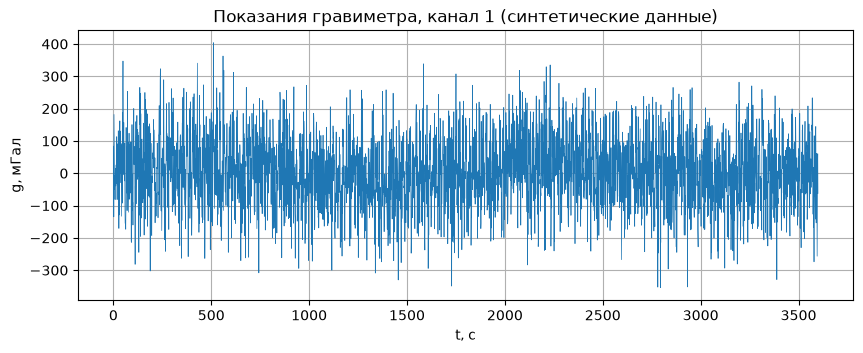

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# СИНТЕТИЧЕСКИЕ данные (заглушка): столбцы t [с], g1 [мГал], g2 [мГал]
data = np.loadtxt('data/gravimeter_synthetic.txt', encoding='utf-8')
t = data[:, 0]
h = data[:, 1:]          # матрица данных: каждый столбец -- отдельный канал
print('размер матрицы данных:', h.shape)

plt.figure(figsize=(10, 3.5))
plt.plot(t, h[:, 0], lw=0.5)
plt.xlabel('t, с')
plt.ylabel('g, мГал')
plt.title('Показания гравиметра, канал 1 (синтетические данные)')
plt.grid(True)
plt.show()

## Весовые окна

В MATLAB окно выбиралось по имени: `wh = feval(winname, nwin)`. В Python функции — обычные объекты, их можно передавать в другие функции как аргументы или хранить в словаре. Это надёжнее, чем вычислять имя строкой (`eval`, `feval`).

Обратите внимание: `hanning(n)` в MATLAB не содержит нулевых концов, а `np.hanning(n)` — содержит. Чтобы получить окно как в MATLAB, возьмите `np.hanning(n + 2)[1:-1]`.

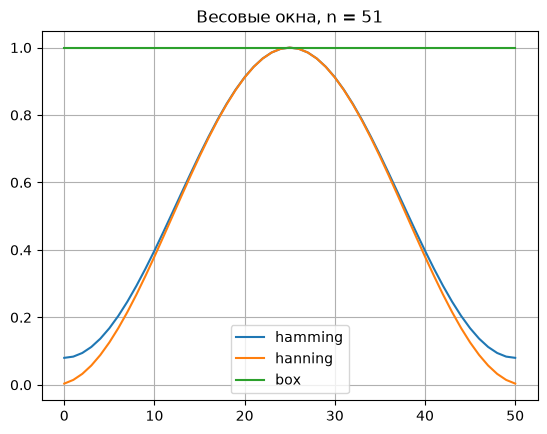

In [2]:
# окна, доступные по имени (аналог выбора функции через feval)
WINDOWS = {
    'hamming': np.hamming,
    'hanning': lambda n: np.hanning(n + 2)[1:-1],   # как hanning в MATLAB
    'box': np.ones,                                 # простое скользящее среднее
}

n = 51
for name, win in WINDOWS.items():
    plt.plot(win(n), label=name)
plt.legend()
plt.title(f'Весовые окна, n = {n}')
plt.grid(True)
plt.show()

## Функция сглаживания: перевод «один в один»

Перевод функции `winsms` с сохранением двойного цикла. Значение по умолчанию задаётся прямо в заголовке функции (в MATLAB для этого проверяли `nargin`).

In [3]:
def winsms_loop(h, nwin, window=WINDOWS['hanning']):
    """
    Сглаживание окном (перевод MATLAB-функции winsms с циклами).

    h      -- матрица данных (N x k), сглаживание по столбцам
    nwin   -- ширина окна
    window -- функция, возвращающая nwin весовых коэффициентов
    Возвращает матрицу (N - nwin + 1) x k.
    """
    wh = window(nwin)
    wh = wh / wh.sum()                     # нормировка: сумма весов равна 1
    N, k = h.shape
    s = np.zeros((N - nwin + 1, k))
    for j in range(k):                     # по каналам
        for i in range(N - nwin + 1):      # по моментам времени
            s[i, j] = np.sum(h[i:i + nwin, j] * wh)
    return s

## Векторизация

Двойной цикл — это свёртка каждого столбца с окном, и её вычисляет функция `np.convolve`. Окно разворачивается (`wh[::-1]`), потому что свёртка «переворачивает» ядро; для симметричных окон это ничего не меняет. Режим `mode='valid'` оставляет только отсчёты, для которых окно целиком помещается в данные, как в цикле.

In [4]:
def winsms(h, nwin, window=WINDOWS['hanning']):
    """Сглаживание окном: векторный вариант через свёртку."""
    wh = window(nwin)
    wh = wh / wh.sum()
    h = np.atleast_2d(h.T).T               # вектор -> столбец
    return np.column_stack([np.convolve(h[:, j], wh[::-1], mode='valid')
                            for j in range(h.shape[1])])


import time
nwin = 301
t0 = time.perf_counter(); s1 = winsms_loop(h, nwin); t1 = time.perf_counter()
s2 = winsms(h, nwin); t2 = time.perf_counter()
print(f'цикл: {t1 - t0:.3f} с, свёртка: {t2 - t1:.4f} с')
print('результаты совпадают:', np.allclose(s1, s2))

цикл: 0.011 с, свёртка: 0.0004 с
результаты совпадают: True


## Результат сглаживания

Сравним окна Хэмминга и фон Ханна. Сглаженный ряд короче исходного на `nwin - 1` отсчётов. Сопоставим каждому значению момент времени в центре окна.

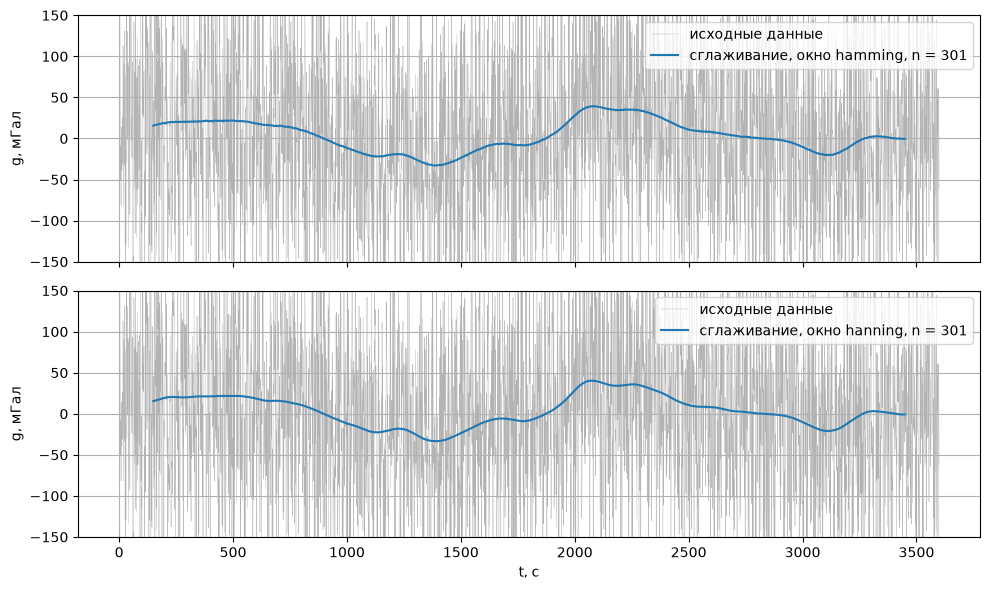

In [5]:
nwin = 301
t_s = t[nwin // 2: len(t) - nwin // 2]        # центры окон

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, name in zip(axes, ['hamming', 'hanning']):
    s = winsms(h, nwin, WINDOWS[name])
    ax.plot(t, h[:, 0], lw=0.3, color='0.7', label='исходные данные')
    ax.plot(t_s, s[:, 0], lw=1.5, label=f'сглаживание, окно {name}, n = {nwin}')
    ax.set_ylim(-150, 150)
    ax.set_ylabel('g, мГал')
    ax.grid(True)
    ax.legend(loc='upper right')
axes[-1].set_xlabel('t, с')
plt.tight_layout()
plt.show()

**Что попробовать:** измените ширину окна `nwin` (51, 301, 901) и сравните, как меняется остаточный шум и насколько «размывается» аномалия около $t = 2200$ с. Сравните окно `box` (простое скользящее среднее) с окнами Хэмминга и фон Ханна.